オリジナル画像 209 枚の拡張を開始します...
拡張完了！ 2090 枚の画像を C:\Users\tokiy\my_GitHub\image-anomaly-detection\data\bottle\train_aug\good に保存しました。


C:\Users\tokiy\AppData\Local\Temp\ipykernel_19908\1353286351.py:85: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tokiy\AppData\Local\Temp\ipykernel_19908\1353286351.py:85: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tokiy\AppData\Local\Temp\ipykernel_19908\1353286351.py:85: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tokiy\AppData\Local\Temp\ipykernel_19908\1353286351.py:85: UserWarning: Glyph 25313 (\N{CJK UNIFIED IDEOGRAPH-62E1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tokiy\AppData\Local\Temp\ipykernel_19908\1353286351.py:85: UserWarning: Glyph 24373 (\N{CJK UNIFIED IDEOGRAPH-5F35}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tokiy\AppData\Local\Temp\ipykernel_19908\1353286351.py:85: UserWarning: Glyph 12398 (\N{HI

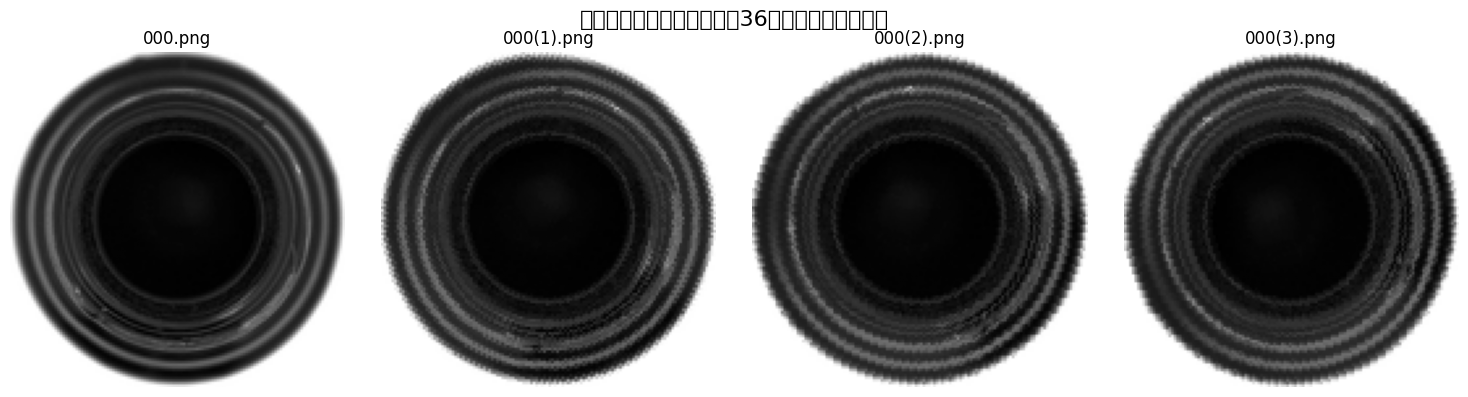

In [1]:
import os
from pathlib import Path
from PIL import Image
from torchvision import transforms
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

# =====================================================================
# 設定
# =====================================================================
INPUT_DIR = r"C:\Users\tokiy\my_GitHub\image-anomaly-detection\data\bottle\train\good"
OUTPUT_DIR = r"C:\Users\tokiy\my_GitHub\image-anomaly-detection\data\bottle\train_aug\good"

# =====================================================================
# ベースとなる前処理パイプライン
# =====================================================================
base_transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1)
])

# =====================================================================
# 実行ブロック
# =====================================================================
input_path = Path(INPUT_DIR)
output_path = Path(OUTPUT_DIR)
output_path.mkdir(parents=True, exist_ok=True)

if not input_path.exists():
    raise FileNotFoundError(f"入力ディレクトリが見つかりません: {input_path}")

image_files = list(input_path.glob("*.png"))
print(f"オリジナル画像 {len(image_files)} 枚の拡張を開始します...")

count = 0
for img_path in image_files:
    img = Image.open(img_path).convert('RGB')
    
    # ベース処理（クロップ＋リサイズ＋グレースケール）を適用
    base_img = base_transform(img)
    
    # 1. 0度（オリジナル）の保存
    # img_path.name を使うことで "000.png" のまま保存します
    base_save_path = output_path / f"{img_path.name}"
    base_img.save(base_save_path)
    count += 1
    
    # 2. 36度ずつ回転させて9枚保存
    for i in range(1, 10):
        angle = i * 36
        aug_img = TF.rotate(base_img, angle=angle, fill=255)
        
        # img_path.stem で "000" を取得し、(i) を付けてから .png を足す
        # これにより "000(1).png", "000(2).png" の形式になります
        aug_save_path = output_path / f"{img_path.stem}({i}){img_path.suffix}"
        aug_img.save(aug_save_path)
        count += 1

print(f"拡張完了！ {count} 枚の画像を {OUTPUT_DIR} に保存しました。")

# =====================================================================
# 生成結果のプレビュー表示
# =====================================================================
sample_img_path = image_files[0]
sample_img = base_transform(Image.open(sample_img_path).convert('RGB'))

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle("データ拡張のプレビュー（36度ずつの均等回転）", fontsize=16)

axes[0].imshow(sample_img, cmap='gray')
# オリジナル画像のファイル名を表示
axes[0].set_title(f"{sample_img_path.name}", fontsize=12)
axes[0].axis('off')

# 拡張画像（36度, 72度, 108度）をプレビュー表示
for i in range(1, 4):
    angle = i * 36
    preview_img = TF.rotate(sample_img, angle=angle, fill=255)
    axes[i].imshow(preview_img, cmap='gray')
    # 拡張画像のファイル名を表示
    axes[i].set_title(f"{sample_img_path.stem}({i}){sample_img_path.suffix}", fontsize=12)
    axes[i].axis('off')

plt.tight_layout()
plt.show()